# Module 6 — Computer Vision at Scale: CLIPSeg-debris

**NHERI SimCenter/DesignSafe 2026 SPARC · Day 3, Session 3b**

[![Try on DesignSafe](https://raw.githubusercontent.com/DesignSafe-CI/training-ai/main/DesignSafe-Badge.svg)](https://jupyter.designsafe-ci.org/hub/user-redirect/lab/tree/CommunityData/Training/2026-SPARC/Day3/Session3b/06-clipseg-debris.ipynb) [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DesignSafe-CI/training-ai/blob/main/06-clipseg/06-clipseg-debris.ipynb)

> **Authors:** Kooshan Amini and Jamie E. Padgett (Rice University) ·
> Padgett Research Group.
> Model: [**CLIPSeg-debris**](https://github.com/Way-Yuhao/CLIPSeg-debris)
> (Amini, Liu, Padgett, Balakrishnan & Veeraraghavan).

---

## A foundation model on real imagery, not a beam

Modules 1-5 built models of a cantilever beam: a regression, a surrogate, an
explanation, a PDE solver, an operator. Small, tabular, self-contained problems
where we always had ground truth to check against.

This module is the other kind of work. A **foundation model** — CLIPSeg, built on
CLIP — fine-tuned to segment **hurricane debris** in post-event aerial imagery as
*no / low-density / high-density*. Real imagery, a published dataset, a GPU, and a
production pipeline that runs on TACC.

What carries over from the earlier modules, and what does not:

| | Modules 1-5 | This module |
| --- | --- | --- |
| Data | 75-1000 simulated cases | published imagery (**PRJ-6029**) + live NOAA rasters |
| Model | written from scratch, thousands of parameters | a **pre-trained foundation model**, ~150 M parameters |
| Training | seconds to minutes on CPU | hours on a **GH200 GPU** |
| Ground truth | a closed-form solution | hand-labelled masks |
| The lesson | how the method works | how to **run someone else's model at scale** |

The model is **not re-implemented here.** We load and run the *official* published
repository (**PRJ-6225**) exactly as distributed — which is itself the point. Most
applied ML is not writing architectures; it is getting a published model to run
correctly on your data, at scale, reproducibly.

## What runs where

Read this before you start, because half of this notebook needs an allocation.

| Part | What it does | Needs | Runs in-session? |
| --- | --- | --- | --- |
| Setup | environment, paths, DAPI login, model, weights | DesignSafe login | yes |
| **1** | official `evaluate()` on the published dataset | GPU session recommended | yes |
| **2** | regional debris map, Estero Island FL, Hurricane Ian | GPU session recommended | yes |
| **3** | scale the same inference out as an HPC GPU job | **TACC allocation** | submit only |
| **4** | fine-tune on Vista (GH200) | **TACC allocation** | submit only |

Parts 1-2 run in a DesignSafe JupyterHub session with no allocation. Parts 3-4
submit real jobs and are shown here from a completed run — read them as the
pattern, and run them later against your own allocation.

**Session note:** in a three-hour session this module is a guided walkthrough
rather than hands-on. Every cell's saved output is committed, so you can follow
the story now and run it yourself afterwards.

## Useful links

- CLIPSeg-debris software — DesignSafe **PRJ-6225** (DOI `10.17603/ds2-yt43-hw55`):
  <https://www.designsafe-ci.org/data/browser/public/designsafe.storage.published/PRJ-6225>
- Debris dataset — DesignSafe **PRJ-6029**:
  <https://www.designsafe-ci.org/data/browser/public/designsafe.storage.published/PRJ-6029>
- Model weights (Hugging Face): <https://huggingface.co/YuhaoL/CLIPSeg-debris>
- **NOAA Emergency Response Imagery** — viewer: <https://storms.ngs.noaa.gov/> ·
  Hurricane Ian (2022): <https://storms.ngs.noaa.gov/storms/ian/index.html#14.4/26.45472/-81.94856> ·
  open data on AWS (`noaa-eri-pds`): <https://registry.opendata.aws/noaa-eri/>
- `dapi` docs: <https://designsafe-ci.github.io/dapi/> · TACC Vista:
  <https://docs.tacc.utexas.edu/hpc/vista/> · Weights & Biases: <https://wandb.ai/>
- Background: CLIPSeg (Lüddecke & Ecker, CVPR 2022) <https://arxiv.org/abs/2112.10003> ·
  CLIP (Radford et al., 2021) <https://arxiv.org/abs/2103.00020>

The long code lives in `utils/`; the notebook holds the headline calls and the
story.

## Environment, paths and imports

In this step, we:

- **install any missing Python packages first**, so the `utils/` imports below
  succeed on a fresh session (e.g. a new TACC Vista session);
- anchor a small, reproducible project layout (`utils/`, `weights/`, `experiments/`);
- put `utils/` on the path and import the demo helpers.


### Install dependencies, then restart the kernel

Installs any missing packages into your environment (to `--user`). On TACC **Vista** /
GPU sessions **PyTorch is already present**; here we add the geospatial + visualization
stack and `dapi`. The model's own dependencies (Hydra, Lightning, `openai-clip`, …)
are installed from the official repo in Step 2.


In [1]:
import os, sys, site, importlib, subprocess

def ensure(pkgs):
    "pip-install (to --user) only the packages that are missing, in one shot."
    missing = []
    for import_name, pip_name in pkgs:
        try:
            importlib.import_module(import_name)
        except ImportError:
            missing.append(pip_name)
    if missing:
        print("installing:", ", ".join(missing), "...")
        subprocess.run([sys.executable, "-m", "pip", "install", "--user", "-q", *missing],
                       check=False)
        # make freshly --user-installed packages importable without a kernel restart
        us = site.getusersitepackages()
        if us not in sys.path:
            sys.path.append(us)
        importlib.invalidate_caches()
    else:
        print("all listed dependencies already present")

ensure([
    ("numpy", "numpy"), ("matplotlib", "matplotlib"),
    ("rasterio", "rasterio"), ("geopandas", "geopandas"), ("pyproj", "pyproj"),
    ("shapely", "shapely"), ("contextily", "contextily"), ("PIL", "pillow"),
    ("tqdm", "tqdm"), ("requests", "requests"), ("cv2", "opencv-python-headless"),
    ("dapi", "dapi"),
])
try:
    import torch
    print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available())
except ImportError:
    print("torch not found — preinstalled on Vista/GPU sessions; "
          "for local inference: pip install torch torchvision")

all listed dependencies already present
torch 2.6.0+cu126 | CUDA: True


### Paths resolve from wherever utils/ lives

Anchor the project root, put `utils/` on the path, and import the demo helpers.


In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Make matplotlib figures render inline (some HPC-Native kernels don't set this).
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR if (NB_DIR / "utils").exists() else NB_DIR.parent
sys.path.insert(0, str(REPO_ROOT))

WEIGHTS_DIR = REPO_ROOT / "weights"; WEIGHTS_DIR.mkdir(exist_ok=True)
EXPERIMENTS = REPO_ROOT / "experiments"; EXPERIMENTS.mkdir(exist_ok=True)

from utils import debris_common as dc
from utils import clipseg_official as co
from utils import regional, viz
from utils import dapi_helpers as dh

print("project root :", REPO_ROOT)
print("on DesignSafe:", dh.on_designsafe())

project root : /data/designsafe/mydata/kooshan1/nheri-training-ai-test/workshop_codes
on DesignSafe: True


## Connect to DesignSafe with DAPI

[`dapi`](https://designsafe-ci.github.io/dapi/) is the DesignSafe API. We use it
throughout to **access published data**, **move files**, and **submit/monitor HPC
jobs**.

In this step, we:

- create an authenticated client with `DSClient()` (prompts for your DesignSafe
  username and password);
- peek at the **apps** and **GPU systems** we will use later (Parts 3–4).

If `dapi` is unavailable (e.g. running off-DesignSafe), the in-session examples
still work — DAPI is used for data access and HPC jobs.


In [3]:
ds = None
try:
    ds = dh.connect()
    try:
        apps = ds.apps.find("agnostic", verbose=False) or []
        print("agnostic app(s):", [getattr(a, "id", a) for a in apps][:5])
    except Exception as e:
        print("apps.find note:", e)
    print("GPU systems on DesignSafe: 'ls6' (NVIDIA A100) and 'vista' (NVIDIA GH200).")
except Exception as e:
    print("DAPI not available here ->", e)
    print("That's OK: the in-session examples below still run.")

Enter DesignSafe Username:  kooshan1
Enter DesignSafe Password:  ········


Authentication successful.
DatabaseAccessor initialized. Connections will be created on first access.
TMS credentials ready: frontera, stampede3, ls6
[dapi] connected to DesignSafe.
agnostic app(s): ['designsafe-agnostic-app', 'demo-agnostic-app', 'agnostic-app']
GPU systems on DesignSafe: 'ls6' (NVIDIA A100) and 'vista' (NVIDIA GH200).


### Every setting you may need to change, in one cell

GPU systems and queues use sensible DesignSafe defaults. Two inputs are **optional**
and only matter for the HPC parts:

- **TACC allocation** (Parts 3–4) — the project your GPU jobs charge to. Enter yours
  to run Parts 3–4, or leave it blank to skip them (Parts 1–2 run without it).
- **W&B API key** (Part 4) — enables the live training dashboard on
  [Weights & Biases](https://docs.wandb.ai/models/track) (experiment tracking).
  Enter it here, or run `wandb login` beforehand; leave it blank to track training via
  DAPI instead. **No W&B account is required to run the demo.**

Both are read at masked prompts and kept in memory only.


In [4]:
import getpass

# --- GPU systems / queues (DesignSafe defaults; rarely need changing) ---
os.environ.setdefault("INFER_SYSTEM", "vista")     # Part 3 inference system
os.environ.setdefault("INFER_QUEUE",  "gh-dev")    # gh-dev: fast scheduling, 2 h cap (gh = 48 h)
os.environ.setdefault("VISTA_SYSTEM", "vista")     # Part 4 training system (GH200)
os.environ.setdefault("VISTA_QUEUE",  "gh-dev")
os.environ.setdefault("WANDB_PROJECT", "clipseg-debris-finetune")  # your W&B project name
os.environ.setdefault("FT_LIMIT", "120")           # debris-positive images for the demo fine-tune
os.environ.setdefault("WANDB_DISABLE_CODE", "true")                # don't upload notebook source to W&B
os.environ.setdefault("WANDB_NOTEBOOK_NAME", "clipseg-debris-designsafe")  # quiets a benign W&B notice

# --- (Optional) TACC allocation for Parts 3 & 4 ---
_alloc = input("TACC allocation for Parts 3-4 [blank = skip the HPC parts]: ").strip()
ALLOCATION = "" if _alloc.lower() in ("", "none", "no", "skip", "n/a") else _alloc
os.environ["TACC_ALLOCATION"] = ALLOCATION

# --- (Optional) Weights & Biases for the Part 4 training dashboard ---
def wandb_ready():
    if os.environ.get("WANDB_API_KEY"):
        return True
    nrc = Path.home() / ".netrc"
    try:
        return nrc.exists() and "api.wandb.ai" in nrc.read_text()
    except Exception:
        return False

if not wandb_ready():
    _key = getpass.getpass("W&B API key [blank = track training via DAPI only]: ").strip()
    if _key and _key.lower() not in ("none", "no", "skip"):
        os.environ["WANDB_API_KEY"] = _key
        try:
            import wandb
            wandb.login(key=_key, relogin=True)      # also writes ~/.netrc for the Vista job
        except Exception as e:
            print("(could not persist ~/.netrc via wandb.login:", e, ")")

USE_WANDB = wandb_ready()
os.environ["USE_WANDB"] = "1" if USE_WANDB else "0"

# Build a W&B dashboard URL from YOUR account (entity is auto-detected, not hard-coded).
PUBLIC_WANDB_URL = ""
if USE_WANDB:
    try:
        import wandb
        _ent = os.environ.get("WANDB_ENTITY") or (wandb.Api().default_entity or "")
        if _ent:
            os.environ["WANDB_ENTITY"] = _ent
            PUBLIC_WANDB_URL = f"https://wandb.ai/{_ent}/{os.environ['WANDB_PROJECT']}"
    except Exception:
        pass
os.environ["PUBLIC_WANDB_URL"] = PUBLIC_WANDB_URL

print("allocation :", ALLOCATION or "(none — Parts 3-4 will be skipped)")
print("inference  :", os.environ["INFER_SYSTEM"], "/", os.environ["INFER_QUEUE"])
print("training   :", os.environ["VISTA_SYSTEM"], "/", os.environ["VISTA_QUEUE"])
print("W&B        :", (f"on (entity: {os.environ.get('WANDB_ENTITY','?')})") if USE_WANDB
      else "off — training will be tracked via DAPI")
if PUBLIC_WANDB_URL:
    print("W&B project:", PUBLIC_WANDB_URL, "(appears once a run logs)")

TACC allocation for Parts 3-4 [blank = skip the HPC parts]:  DesignSafe-Padgett


wandb: WARNING WANDB_NOTEBOOK_NAME should be a path to a notebook file, couldn't find clipseg-debris-designsafe.
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home1/06009/kooshan1/.netrc.


allocation : DesignSafe-Padgett
inference  : vista / gh-dev
training   : vista / gh-dev
W&B        : on (entity: kooshan1)
W&B project: https://wandb.ai/kooshan1/clipseg-debris-finetune (appears once a run logs)


## Load the official CLIPSeg-debris software (PRJ-6225)

Rather than re-implementing the model, we use the **official research software**.
`resolve_repo()` obtains it (in order of preference):

1. an existing checkout in this project, else
2. the **DesignSafe published software PRJ-6225** (mounted on JupyterHub), else
3. a `git clone` of the GitHub release (`v1.0.1`).

It then puts the repo on `sys.path`. We also install the repo's own requirements
(Hydra, Lightning, `openai-clip`, …). This is the same official code used for both
the published-dataset inference (Part 1) and the regional pipeline (Part 2).


In [5]:
REPO = co.resolve_repo(REPO_ROOT)        # -> <project>/CLIPSeg-debris, added to sys.path
co.install_requirements(REPO)            # Hydra / Lightning / openai-clip / ...
print("official repo:", REPO)
print("exists:", (REPO / "src" / "eval.py").exists())

[clipseg] using existing repo: /data/designsafe/mydata/kooshan1/nheri-training-ai-test/workshop_codes/CLIPSeg-debris


/opt/apps/gcc14/cuda12/python3/3.11.8/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: '/opt/apps/gcc14/cuda12/python3/3.11.8/lib/python3.11/site-packages/torchvision/image.so: ELF load command address/offset not properly aligned'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


[clipseg] installing official runtime deps: hydra-colorlog
official repo: /data/designsafe/mydata/kooshan1/nheri-training-ai-test/workshop_codes/CLIPSeg-debris
exists: True



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## Weights come from Hugging Face or DesignSafe at run time

The official `evaluate()` loads a **Lightning checkpoint** (`.ckpt`). We resolve it
in order: a local file in `weights/` → **DesignSafe** via DAPI (set
`DS_WEIGHTS_URI`, e.g. `/MyData/clipseg_debris/clipseg_debris_weight.ckpt`) →
**Hugging Face** fallback.


In [6]:
def resolve_weights():
    for name in ("clipseg_debris_weight.ckpt", "clipseg_debris.safetensors"):
        p = WEIGHTS_DIR / name
        if p.exists():
            return p
    ds_uri = os.environ.get("DS_WEIGHTS_URI")        # your DesignSafe path, optional
    if ds is not None and ds_uri:
        dest = WEIGHTS_DIR / Path(ds_uri).name
        print(f"downloading weights from DesignSafe: {ds_uri}")
        dh._ds_download(ds, ds.files.to_uri(ds_uri), dest); return dest  # robust (getContents)
    import urllib.request
    url = ("https://huggingface.co/YuhaoL/CLIPSeg-debris/resolve/main/"
           "clipseg_debris_weight.ckpt")
    dest = WEIGHTS_DIR / "clipseg_debris_weight.ckpt"
    print("downloading weights (.ckpt) from Hugging Face ...")
    urllib.request.urlretrieve(url, dest); return dest

CKPT = resolve_weights()
print("weights:", CKPT)

weights: /data/designsafe/mydata/kooshan1/nheri-training-ai-test/workshop_codes/weights/clipseg_debris_weight.ckpt


## Part 1 — Official inference on the published dataset (PRJ-6029)

The published **PRJ-6029** debris dataset is mounted read-only on DesignSafe under
`/home/jupyter/NHERI-Published/...`. In this step, we:

- locate the dataset's `original/` images;
- copy a small **showcase** subset into an `experiments/` input folder.


In [7]:
import shutil

PRJ6029_SUB = "Project--hurricane-induced-debris-segmentation-dataset-using-aerial-imagery--V2/data"
showcase = ["000363", "000325", "000357", "020440", "000226",
            "013127", "020243", "002476", "020487", "000029"]
files = [f"post-rgb-{i}_merged_50m.png" for i in showcase]

import tempfile
# The official dataset derives each image id from its path, so we stage the showcase
# images into a hyphen-free input directory to keep the ids unambiguous.
_cands = [Path.home() / "clipseg_part1_inputs",
          Path(tempfile.gettempdir()) / "clipseg_part1_inputs"]
input_dir = next((c for c in _cands if "-" not in str(c)), _cands[0])
input_dir.mkdir(parents=True, exist_ok=True)
for f in input_dir.glob("*"):
    if f.is_file():           # skip dirs like .ipynb_checkpoints
        f.unlink()

DATASET = dh.published_mount("PRJ-6029", PRJ6029_SUB)
IMAGES = (DATASET / "original") if DATASET else None
n = 0
if IMAGES and IMAGES.exists():
    # (a) filesystem mount — available on the regular JupyterHub VM
    for fn in files:
        src = IMAGES / fn
        if src.exists():
            shutil.copy(src, input_dir / fn); n += 1
    print(f"copied {n} showcase images from the NHERI-Published mount -> {input_dir}")
elif ds is not None:
    # (b) no mount (e.g. Jupyter HPC-Native on Vista) -> fetch via DAPI's
    #     publications API, which resolves the published location for us.
    print("NHERI-Published not mounted here; fetching PRJ-6029 showcase via DAPI "
          "publications API ...")
    n = dh.download_published_files(
        ds, "PRJ-6029",
        [f"/{PRJ6029_SUB}/original/", f"/{PRJ6029_SUB}/original"],
        files, input_dir)
    print(f"downloaded {n} showcase images via DAPI -> {input_dir}")
else:
    print("No mount and no DAPI -> Part 1 skipped; Part 2 builds imagery from NOAA.")
print("Part 1 images ready:", n)

if n == 0:
    # Fallback (e.g. on Vista, where the published mount/DAPI path isn't available):
    # use a few LIVE NOAA Estero tiles so the official evaluate() still runs on real
    # post-hurricane imagery. Files are named so the official dataset can read them.
    print("\nPublished dataset not reachable here — using live NOAA Estero tiles for "
          "the Part 1 showcase ...")
    _p1 = regional.RegionalDebrisDemo(center_lat=26.456753, center_lon=-81.959124,
                                      n_cells=3, cell_size_m=50.0, target_pixels=256,
                                      workdir=str(EXPERIMENTS / "part1_fallback"))
    _p1.fetch_imagery(progress=False)
    _p1.export_tiles_png(input_dir)
    n = len(list(input_dir.glob("post-rgb-*.png")))
    print(f"prepared {n} NOAA Estero tiles for Part 1 -> {input_dir}")
    print("(On the regular JupyterHub the published PRJ-6029 dataset is used instead.)")

NHERI-Published not mounted here; fetching PRJ-6029 showcase via DAPI publications API ...
  [dapi] published project: /published-data/PRJ-6029 (3 entries)
  [dapi] entity: Project--hurricane-induced-debris-segmentation-dataset-using-aerial-imagery--V2
  [dapi] downloaded 10/10 from published-data/PRJ-6029/Project--hurricane-induced-debris-segmentation-dataset-using-aerial-imagery--V2/data/original
downloaded 10 showcase images via DAPI -> /home1/06009/kooshan1/clipseg_part1_inputs
Part 1 images ready: 10


### The published `evaluate()`, unmodified

We drive the model's **own** Hydra entry point, `src.eval.evaluate`. We:

- choose **GPU** if available, else CPU;
- compose the `eval` config with our checkpoint, input directory, and output
  location;
- call `evaluate(cfg)`, which writes input/prediction overlays under
  `experiments/demo/`.


In [8]:
ran_part1 = False
if n > 0:
    import torch
    from hydra import compose, initialize_config_dir
    from src.eval import evaluate                      # official entry point

    # The Jupyter session runs inside a SLURM job; stop Lightning auto-detecting it.
    co.disable_slurm_env()

    use_gpu = torch.cuda.is_available()
    dev = (["trainer.accelerator=gpu", "trainer.devices=[0]"] if use_gpu
           else ["trainer.accelerator=cpu", "trainer.devices=1"])
    print("CUDA available:", use_gpu)

    with initialize_config_dir(version_base="1.2",
                               config_dir=str(REPO / "configs"), job_name="demo"):
        cfg = compose(config_name="eval", overrides=[
            f"ckpt_path={CKPT}",
            f"data.query_images_dir={input_dir}",
            f"+local.prediction_output_dir={EXPERIMENTS}",
            f"+local.data_dir={input_dir}",
            "name=demo",
        ] + dev)
    evaluate(cfg)                                       # official inference
    ran_part1 = True
    print("✅ official evaluate() complete -> experiments/demo/predictions")
else:
    print("Skipped (no showcase images here).")

Seed set to 42


CUDA available: True


[rank: 0] No logger configs found! Skipping...
/home1/06009/kooshan1/.local/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /opt/apps/gcc14/cuda12/python3/3.11.8/lib/python ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GH200 120GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Restoring states from the checkpoint path at /data/designsafe/mydata/kooshan1/nheri-training-ai-test/workshop_codes/weights/clipseg_

Predicting: |          | 0/? [00:00<?, ?it/s]

✅ official evaluate() complete -> experiments/demo/predictions


### Predictions against hand-labelled masks

For each image we show the **input** and the model's **debris overlay** side by
side (these are the files `evaluate()` just wrote).


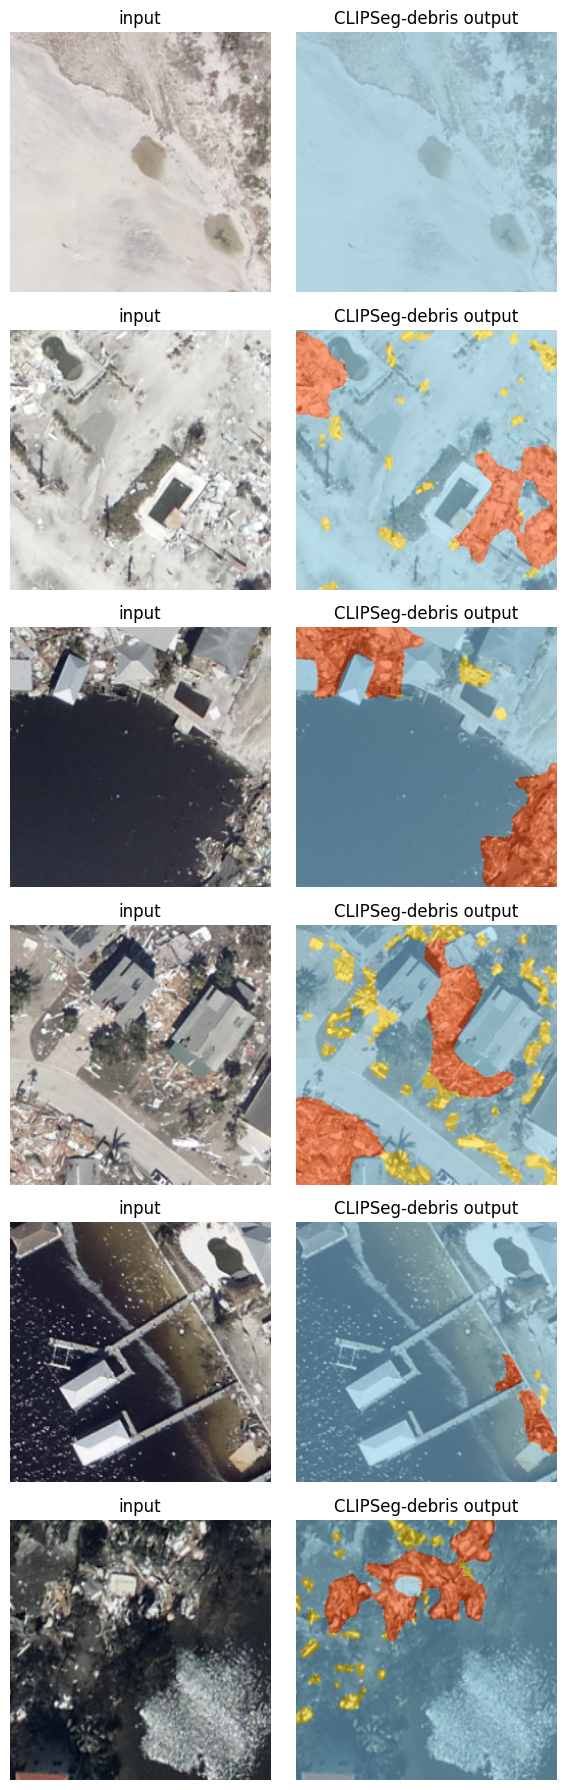

In [9]:
if ran_part1:
    import cv2
    pred_dir = EXPERIMENTS / "demo" / "predictions"
    orig_dir = EXPERIMENTS / "demo" / "original"
    pairs = sorted(zip(sorted(orig_dir.glob("*.png")), sorted(pred_dir.glob("*.png"))))[:6]
    fig, axes = plt.subplots(len(pairs), 2, figsize=(6, 3 * len(pairs)))
    for ax_row, (o, p) in zip(np.atleast_2d(axes), pairs):
        ax_row[0].imshow(cv2.cvtColor(cv2.imread(str(o)), cv2.COLOR_BGR2RGB))
        ax_row[0].set_title("input"); ax_row[0].axis("off")
        ax_row[1].imshow(cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB))
        ax_row[1].set_title("CLIPSeg-debris output"); ax_row[1].axis("off")
    fig.tight_layout(); display(fig); plt.close(fig)
else:
    print("Run Part 1 above (needs the dataset via mount or DAPI) to see predictions.")

## Part 2 — A regional example: Estero Island, FL

Now we go beyond single images to a **region**. We build a **10×10 block of 50 m
cells** centered on `(26.456753, -81.959124)` — Fort Myers Beach / Estero Island,
the model's training region — and pull the matching **NOAA Emergency Response
Imagery** for **[Hurricane Ian (2022)](https://storms.ngs.noaa.gov/storms/ian/index.html#14.4/26.45472/-81.94856)**.
You can browse the very same aerial imagery in NOAA's interactive
[storm viewer](https://storms.ngs.noaa.gov/).

`RegionalDebrisDemo` (in `utils/regional.py`) wraps the same logic as the
production regional pipeline. In this step, we build the grid and view it over an
aerial basemap.


RegionalDebrisDemo(center=(26.456753, -81.959124), 10x10 cells of 50 m -> 500 m square)
  CRS=EPSG:26917  bounds=(np.float64(404134.6), np.float64(2926374.5), np.float64(404634.6), np.float64(2926874.5))
  ERI source=20220930d_RGB
  workdir=/data/designsafe/mydata/kooshan1/nheri-training-ai-test/workshop_codes/experiments/estero_regional


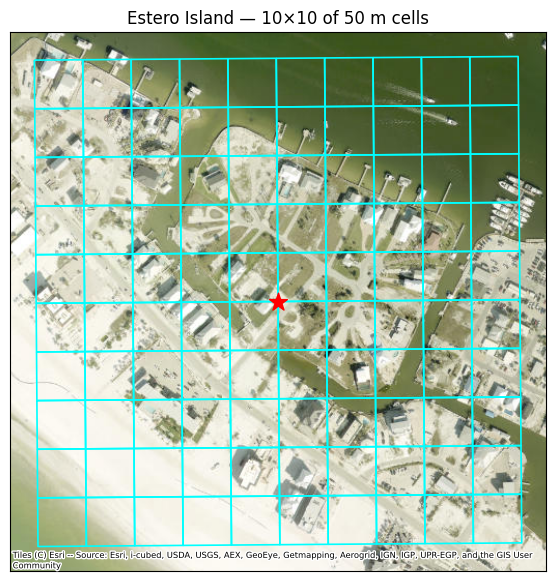

In [10]:
demo = regional.RegionalDebrisDemo(
    center_lat=26.456753, center_lon=-81.959124,
    n_cells=10, cell_size_m=50.0, target_pixels=256,
    workdir=str(EXPERIMENTS / "estero_regional"),
)
print(demo.describe())

grid = demo.build_grid()
ax = viz.show_grid_on_basemap(
    grid, center_lonlat=(demo.center_lat, demo.center_lon),
    title=f"Estero Island — {demo.n_cells}×{demo.n_cells} of {demo.cell_size_m:.0f} m cells")
display(ax.figure); plt.close(ax.figure)

### NOAA ERI rasters for Hurricane Ian

For every cell we fetch the corresponding NOAA ERI tile straight from NOAA's public
S3 bucket ([`noaa-eri-pds` on AWS Open Data](https://registry.opendata.aws/noaa-eri/))
using **windowed reads** (only the bytes overlapping each cell are downloaded),
reprojected/resampled to a 256×256 RGB GeoTIFF.


[regional] tile index '20220930d_RGB': 1818 tiles (tile_index_20220930d_RGB.shp)


NOAA ERI tiles:   0%|          | 0/100 [00:00<?, ?it/s]

[regional] fetched 100 cells; 100 with >50% imagery coverage.


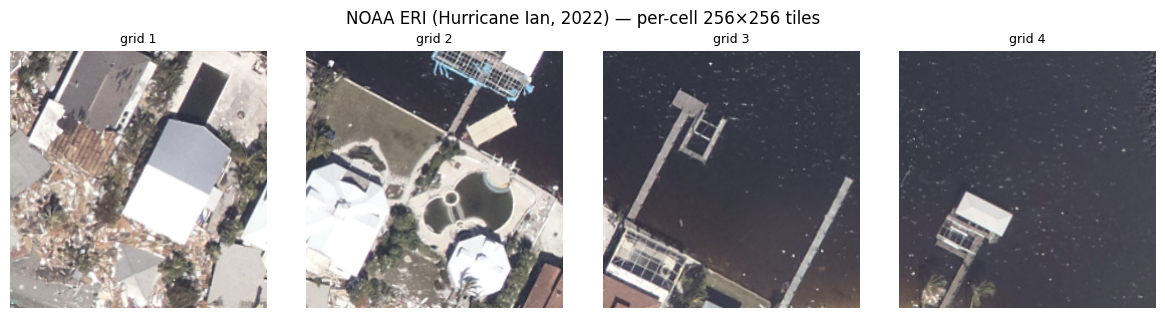

In [11]:
paths = demo.fetch_imagery(overwrite=False)

import rasterio
sample = sorted(paths.items())[:4]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, (gid, p) in zip(axes, sample):
    with rasterio.open(p) as s:
        ax.imshow(s.read([1, 2, 3]).transpose(1, 2, 0))
    ax.set_title(f"grid {gid}", fontsize=9); ax.axis("off")
fig.suptitle("NOAA ERI (Hurricane Ian, 2022) — per-cell 256×256 tiles")
fig.tight_layout(); display(fig); plt.close(fig)

### Cell-by-cell inference across the grid

We load the **official** `CLIPDensePredT` from the repo we set up in Step 2 and run
it on the cells. `predict_image()` reproduces the repo's `predict_step` (prompt
with `"a photo of {density}"` for the 3 densities, stack, forward, `argmax`).

We preview the model's debris overlay on a few cells, then run the full 10×10 block
(small and fast on a GPU session).


[clipseg] official CLIPDensePredT loaded (150.8M params) from clipseg_debris_weight.ckpt; device=cuda


CLIPSeg-debris:   0%|          | 0/4 [00:00<?, ?it/s]

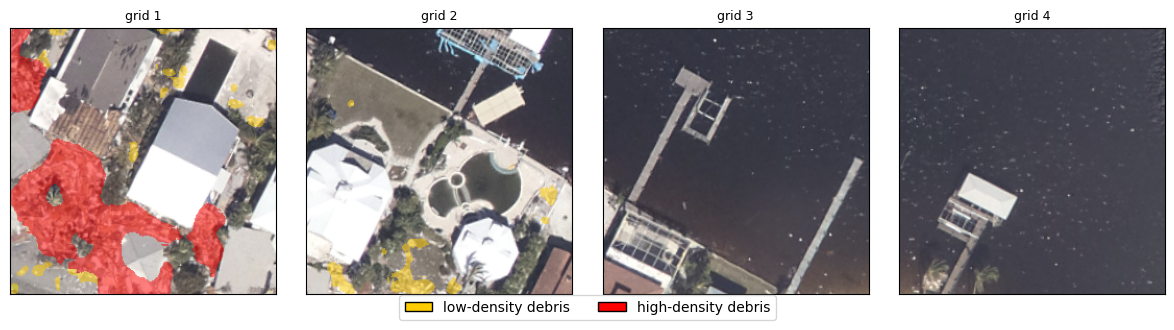

In [12]:
model = None
try:
    model = co.load_model(REPO, CKPT, device=co.get_device())
except Exception as e:
    print("Could not load the model here (needs torch + the repo deps):", e)

if model is not None:
    # preview the model on the same first 4 grid cells shown above
    gids = sorted(demo._imagery_paths)[:4]
    imgs = [dc.load_rgb(demo._imagery_paths[g]) for g in gids]
    masks = co.predict_images(model, imgs, progress=True)
    fig = viz.show_overlay_row(imgs, masks, titles=[f"grid {g}" for g in gids])
    display(fig); plt.close(fig)

### The assembled debris map for Estero Island

We run the official model over **all** cells (writing georeferenced mask GeoTIFFs),
mosaic the imagery and masks into regional rasters, and show the imagery alongside
the CLIPSeg-debris overlay across the island.


CLIPSeg-debris:   0%|          | 0/100 [00:00<?, ?it/s]

[regional] wrote imagery mosaic -> /data/designsafe/mydata/kooshan1/nheri-training-ai-test/workshop_codes/experiments/estero_regional/mosaic_imagery.tif
[regional] wrote mask mosaic -> /data/designsafe/mydata/kooshan1/nheri-training-ai-test/workshop_codes/experiments/estero_regional/mosaic_mask.tif


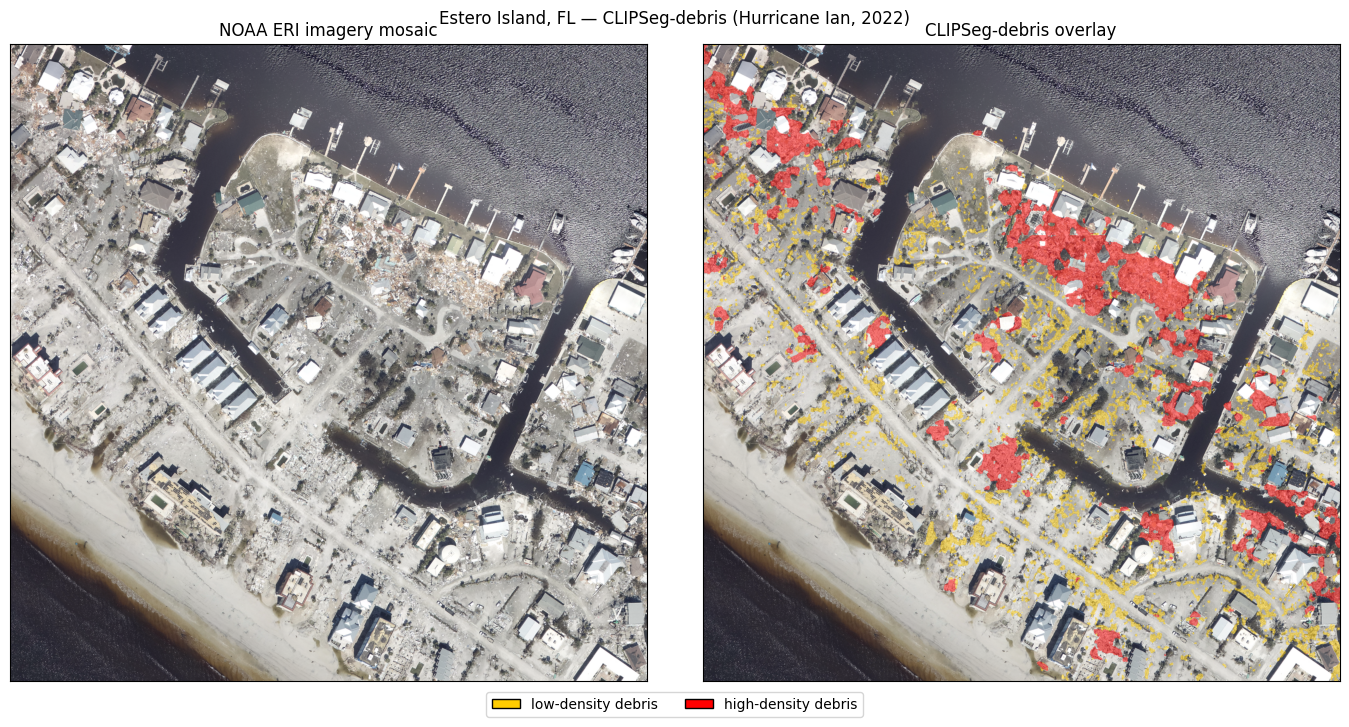

In [13]:
if model is not None:
    demo.run_inference(model=model, write_masks=True, progress=True)   # all cells
    img_mosaic = demo.mosaic("imagery")
    mask_mosaic = demo.mosaic("mask")

    fig = viz.show_region_mosaic(
        img_mosaic, mask_mosaic,
        title="Estero Island, FL — CLIPSeg-debris (Hurricane Ian, 2022)")
    display(fig); plt.close(fig)
else:
    print("Load the model above to build the regional map.")

## Part 3 — Scale out with a DAPI HPC GPU job

A single island fits in the notebook session; a **whole region** (thousands of
cells) does not. For that we ship the work to a **GPU HPC node** with `dapi`. The
recipe:

1. **Bundle** a self-contained job: the inference driver + thin helpers + weights +
   the input tiles (`build_inference_bundle`). The node clones the *official* repo.
2. **Upload** it to DesignSafe storage (`upload_dir`).
3. **Generate + submit** a Tapis job on a GPU queue (`generate_inference_job`,
   `submit_and_monitor`).
4. **Download** the resulting georeferenced masks.

If you entered a `TACC_ALLOCATION` in Step 1b, this submits the job and downloads the
masks; otherwise it builds the bundle and stops (the in-session map above already
shows the result for Estero).


In [14]:
ALLOCATION = os.environ.get("TACC_ALLOCATION", "")
INFER_SYSTEM = os.environ.get("INFER_SYSTEM", "vista")
INFER_QUEUE = os.environ.get("INFER_QUEUE", "gh-dev")

if ds is not None and ALLOCATION:
    try:
        display(dh.gpu_queues(ds, INFER_SYSTEM))    # inspect queues/limits
    except Exception as e:
        print("queue lookup note:", e)

bundle = dh.build_inference_bundle(
    bundle_dir=EXPERIMENTS / "estero_regional" / "job_bundle",
    utils_dir=REPO_ROOT / "utils",
    job_dir=REPO_ROOT / "designsafe_job",
    weights_path=CKPT,
    input_tiles_dir=demo.imagery_dir,
)

Credentials already exist for user 'kooshan1' on system 'vista'. No action taken.


,name,hpcQueue,maxNodes,maxCoresPerNode,maxMinutes,maxMemoryMB,maxJobsPerUser
0,gg,gg,32,144,2880,237000,40
1,gh,gh,64,72,2880,96000,40
2,gh-dev,gh-dev,8,72,120,96000,3


[dapi] inference bundle ready at /data/designsafe/mydata/kooshan1/nheri-training-ai-test/workshop_codes/experiments/estero_regional/job_bundle (100 input tiles)


In [15]:
if ds is not None and ALLOCATION:
    remote = ds.files.to_uri("/MyData/clipseg_debris_demo/estero_infer")
    dh.upload_dir(ds, bundle, remote)
    req = dh.generate_inference_job(
        ds, input_dir_uri=remote, allocation=ALLOCATION,
        system=INFER_SYSTEM, queue=INFER_QUEUE,
        weights_filename=CKPT.name, max_minutes=30, job_name="clipseg-debris-estero")
    job = dh.submit_and_monitor(ds, req, timeout_minutes=30)
    # Find + download the mask GeoTIFFs from the archive (robust to where Tapis
    # nests outputs/, e.g. under inputDirectory/).
    got = dh.download_job_outputs(ds, job, demo.mask_dir, pattern="*-mask.tif", verbose=True)
    if got:
        print(f"\n{got} masks -> {demo.mask_dir}  (re-run Part 6 to mosaic them)")
    else:
        # Nothing matched: show what the job actually printed + the archive tree
        # so we can see whether inference ran and where the files landed.
        print("\nNo masks downloaded — showing the job's own log (tapisjob.out):")
        try:
            dh.show_job_logs(job, max_lines=60)
        except Exception as ex:
            print("   log unavailable:", ex)
        print("\nArchive tree (dirs + *-mask.tif):")
        dh.print_job_tree(ds, job, max_depth=4)
else:
    print("No TACC allocation set (Step 1b) — skipping submission. Bundle ready at:", bundle)

Translated '/MyData/clipseg_debris_demo/estero_infer' to 'tapis://designsafe.storage.default/kooshan1/clipseg_debris_demo/estero_infer' using t.username
[dapi] uploaded 105 file(s) -> tapis://designsafe.storage.default/kooshan1/clipseg_debris_demo/estero_infer
Translated '/MyData' to 'tapis://designsafe.storage.default/kooshan1' using t.username
[dapi] submitted 1ab852ba-21bf-49e7-a53b-01cbb3a8c78e-007 -> vista/gh-dev

Monitoring Job: 1ab852ba-21bf-49e7-a53b-01cbb3a8c78e-007


Waiting for job to start: 0 checks [00:00, ? checks/s]

Monitoring job:   0%|          | 0/120 [00:00<?, ? checks/s]

	Status: RUNNING
	Status: ARCHIVING
	Status: FINISHED
[dapi] status after monitor: FINISHED
[dapi] downloaded 100 file(s) matching '*-mask.tif' from inputDirectory/outputs/mask_tif -> /data/designsafe/mydata/kooshan1/nheri-training-ai-test/workshop_codes/experiments/estero_regional/masks

100 masks -> /data/designsafe/mydata/kooshan1/nheri-training-ai-test/workshop_codes/experiments/estero_regional/masks  (re-run Part 6 to mosaic them)


## Part 4 — Fine-tune CLIPSeg-debris on Vista (TACC GH200) via DAPI

DesignSafe gives us TACC's newest AI system,
**[Vista](https://docs.tacc.utexas.edu/hpc/vista/)** — **NVIDIA GH200
Grace-Hopper** nodes. We launch the model's **official fine-tuning**
(`src/train.py experiment=clipseg_finetune`) on a Vista GPU and track progress on
**Weights & Biases** (if you provided a key in Step 1b) or via **DAPI**.

Fine-tuning needs the labeled debris data. The published **PRJ-6029** dataset has
everything (`original/`, `annotations/`, `prompts_vis/{no,low,high}/`) but in a
slightly different layout than the trainer's `DebrisOneHotDataset`
(`original/`, `segmentation_merged/`, `vis_prompts/...`). So we **prepare** it
(convert annotations → one-hot, rename folders), **verify** it loads, then
**bundle it with the job** (Vista compute nodes don't mount MyData).


### Reshape PRJ-6029 into the official datamodule layout

`obtain_and_prepare` fetches the published **PRJ-6029** data on this session (via the
NHERI-Published mount, the TACC corral filesystem, or the DesignSafe files API),
converts it to the trainer's `DebrisOneHotDataset` layout (annotations → 3-channel
one-hot, folder names), and writes it to **MyData** (shared with Vista). `FT_LIMIT`
subsamples for a quick demo. If the data can't be reached here, it prints a short
diagnostic with next steps.


In [16]:
from utils import finetune_data as fd

PRJ6029_SUB = "Project--hurricane-induced-debris-segmentation-dataset-using-aerial-imagery--V2/data"
ALLOCATION    = os.environ.get("TACC_ALLOCATION", "")
WANDB_PROJECT = os.environ.get("WANDB_PROJECT", "clipseg-debris-finetune")
WANDB_ENTITY  = os.environ.get("WANDB_ENTITY", "")
VISTA_SYSTEM  = os.environ.get("VISTA_SYSTEM", "vista")
VISTA_QUEUE   = os.environ.get("VISTA_QUEUE", "gh-dev")
FT_LIMIT      = int(os.environ.get("FT_LIMIT", "120"))   # debris-positive images to use (0 = all)

prepared = (dh.mydata_dir() or EXPERIMENTS) / "clipseg_finetune_data"
if prepared.exists() and (prepared / "original").exists():
    print("Using previously prepared dataset:", prepared)
    os.environ["CLIPSEG_DATASET_DIR"] = str(prepared)
else:
    # Obtain on THIS session, trying in order: NHERI-Published mount ->
    # TACC corral filesystem -> DAPI publications download. Then convert.
    result = fd.obtain_and_prepare(
        ds, out_dir=prepared, prj="PRJ-6029",
        mount_dir=dh.published_mount("PRJ-6029", PRJ6029_SUB),
        limit=(FT_LIMIT or None))
    if result:
        os.environ["CLIPSEG_DATASET_DIR"] = str(result)

DATASET_DIR = os.environ.get("CLIPSEG_DATASET_DIR", "")
print("\nCLIPSEG_DATASET_DIR =", DATASET_DIR or "(not set)")

Using previously prepared dataset: /data/designsafe/mydata/kooshan1/clipseg_finetune_data

CLIPSEG_DATASET_DIR = /data/designsafe/mydata/kooshan1/clipseg_finetune_data


### Verify the prepared dataset loads in the official datamodule (diagnostic)


In [17]:
if DATASET_DIR and Path(DATASET_DIR).exists():
    fd.verify_finetune_dataset(REPO, DATASET_DIR, n=2)
else:
    print("No prepared dataset yet — see 7a.")

[finetune-data] DebrisOneHotDataset OK — 120 samples; sample ids ['000055', '000126', '000135', '000139', '000146']
  sample 0: image (3, 256, 256), target (1, 256, 256)
  sample 1: image (3, 256, 256), target (1, 256, 256)


### Fine-tuning submitted to Vista via DAPI

Bundle the prepared dataset with the job and submit it to the GH200 `gh-dev` queue,
then follow the **job lifecycle** via DAPI. If you enabled W&B in Step 1b, the run
also streams **live curves** there (the node authenticates via your `~/.netrc`; the
key is never placed in the job). Requires a TACC allocation (Step 1b) and a prepared
dataset (7a).


In [18]:
train_job = None
USE_WANDB = os.environ.get("USE_WANDB", "0") == "1"
ready = (ds is not None and ALLOCATION and DATASET_DIR and Path(DATASET_DIR).exists())
if ready:
    try:
        display(dh.gpu_queues(ds, VISTA_SYSTEM))
    except Exception as e:
        print("vista queue note:", e)
    train_bundle = dh.build_training_bundle(
        bundle_dir=EXPERIMENTS / "train_bundle", job_dir=REPO_ROOT / "designsafe_job",
        dataset_dir=DATASET_DIR)                       # dataset travels with the job
    remote = ds.files.to_uri("/MyData/clipseg_debris_demo/train")
    dh.upload_dir(ds, train_bundle, remote)
    req = dh.generate_training_job(
        ds, input_dir_uri=remote, allocation=ALLOCATION, use_wandb=USE_WANDB,
        wandb_project=WANDB_PROJECT, wandb_entity=WANDB_ENTITY,
        system=VISTA_SYSTEM, queue=VISTA_QUEUE, max_minutes=110, max_epochs=10)  # <2h gh-dev cap
    train_job = dh.submit(ds, req)                     # non-blocking
    if USE_WANDB:
        print("Training queued on Vista — watch live curves on W&B (next cell).")
    else:
        print("Training queued on Vista (tracking via DAPI — no W&B configured).")
    print("Re-check status anytime with:  dh.job_status(ds, train_job)")
else:
    print("Not ready to submit. Need a TACC allocation (Step 1b) and a prepared")
    print("dataset (CLIPSEG_DATASET_DIR from 7a).")

Credentials already exist for user 'kooshan1' on system 'vista'. No action taken.


,name,hpcQueue,maxNodes,maxCoresPerNode,maxMinutes,maxMemoryMB,maxJobsPerUser
0,gg,gg,32,144,2880,237000,40
1,gh,gh,64,72,2880,96000,40
2,gh-dev,gh-dev,8,72,120,96000,3


[dapi] training bundle ready at /data/designsafe/mydata/kooshan1/nheri-training-ai-test/workshop_codes/experiments/train_bundle (480 dataset file(s) staged)
Translated '/MyData/clipseg_debris_demo/train' to 'tapis://designsafe.storage.default/kooshan1/clipseg_debris_demo/train' using t.username
[dapi] uploaded 481 file(s) -> tapis://designsafe.storage.default/kooshan1/clipseg_debris_demo/train
Translated '/MyData' to 'tapis://designsafe.storage.default/kooshan1' using t.username
[dapi] submitted 2dedaf2e-e93f-4737-a639-e07efd3ef62b-007 -> vista/gh-dev
[dapi] status: PENDING
Training queued on Vista — watch live curves on W&B (next cell).
Re-check status anytime with:  dh.job_status(ds, train_job)


### Progress streams to Weights & Biases or DAPI

If you enabled **[W&B](https://docs.wandb.ai/models/track)** in Step 1b, this shows a
clickable link to the live dashboard plus the newest run's loss / IoU / Dice curves
pulled **inline via the W&B API**
(re-run to refresh). `wandb.ai` can't be embedded in a notebook iframe, so we use a
link + inline plots — set the project to *public* so others can open it without an
account. Without W&B, track the job through **DAPI**: its status and the per-epoch
metrics printed in the job log.


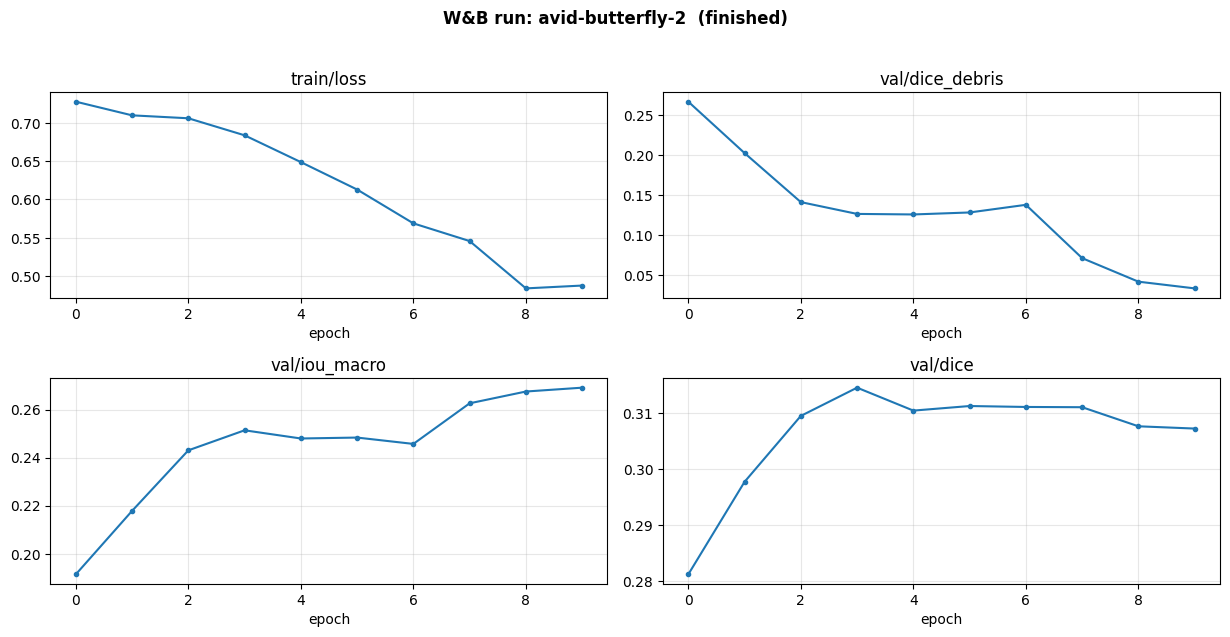

newest run: avid-butterfly-2 -> https://wandb.ai/kooshan1/clipseg-debris-finetune/runs/9llr1vle


In [23]:
PUBLIC_WANDB_URL = os.environ.get("PUBLIC_WANDB_URL", "")
if PUBLIC_WANDB_URL:
    # Clickable dashboard link + inline metric curves from the W&B API (no iframe).
    dh.wandb_panel(PUBLIC_WANDB_URL,
                   entity=os.environ.get("WANDB_ENTITY", ""),
                   project=os.environ.get("WANDB_PROJECT", ""))
elif train_job is not None:
    # No W&B configured — track via DAPI: current status + where to read the metrics.
    dh.job_status(ds, train_job)
    print("\nPer-epoch metrics print in the job log:  dh.show_job_logs(train_job)")
else:
    print("No training job submitted yet — see 7c (needs a TACC allocation + dataset).")

## Exercises: change the prompt, the region, the grid

Module 6 has no separate exercise notebook — blanking out the code of a production
pipeline mostly just breaks it. The exercises are variations to make instead, in
rough order of effort:

1. **Change the prompt.** CLIPSeg is *text-prompted*: the class names are an input,
   not a fixed head. Find where the prompts are set and try wording variants
   ("rubble", "storm debris", "damaged building material"). How much does the map
   move? This is the property that separates a foundation model from a fixed
   classifier, and it is worth feeling directly.
2. **Change the region.** Pass a different `ERISource` from
   `utils/regional.ERI_SOURCES` with a new `center_lat` / `center_lon` — another
   part of Estero Island, or a different hurricane entirely.
3. **Change the grid.** Raise `n_cells` from the 10x10 block. Where does an
   in-session run stop being practical? That answer is why Part 3 exists.
4. **Read the failure cases.** Find cells where the model is confidently wrong.
   Water, shadow, and bare roofs are the usual suspects. Connect this back to
   Module 3: what would you want a SHAP-style explanation of here, and why is
   attribution much harder for a segmentation model than for a decision tree?
5. **With an allocation:** run Part 3 end to end, then fine-tune in Part 4 and
   compare against the published weights on the same grid.

## Adapting this to another region, storm or dataset

- **Other regions / hurricanes**: pass a different `ERISource`
  (`utils/regional.ERI_SOURCES`) and a new `center_lat/center_lon`, or raise
  `n_cells` to cover more ground.
- **True regional scale**: the Part 3 HPC pattern scales to thousands of cells.
- **Training**: Part 4 runs the official `src/train.py` on Vista; adjust the
  `data=` override in `designsafe_job/train_clipseg.sh` to your dataset layout.
- **Where the pieces live**: official model + inference in `utils/clipseg_official.py`
  (no vendoring); grid + NOAA ERI in `utils/regional.py`; DesignSafe API + HPC/Vista
  jobs in `utils/dapi_helpers.py`; the job scripts in `designsafe_job/`.

### Citations

If you use this work, please cite:

**Paper** — Amini et al., *Debris segmentation using post-hurricane aerial imagery*,
Computer-Aided Civil and Infrastructure Engineering, 2025:

```bibtex
@article{https://doi.org/10.1111/mice.70033,
  author  = {Amini, Kooshan and Liu, Yuhao and Padgett, Jamie Ellen and Balakrishnan, Guha and Veeraraghavan, Ashok},
  title   = {Debris segmentation using post-hurricane aerial imagery},
  journal = {Computer-Aided Civil and Infrastructure Engineering},
  volume  = {40},
  number  = {25},
  pages   = {4116-4131},
  doi     = {https://doi.org/10.1111/mice.70033},
  url     = {https://onlinelibrary.wiley.com/doi/abs/10.1111/mice.70033},
  eprint  = {https://onlinelibrary.wiley.com/doi/pdf/10.1111/mice.70033},
  year    = {2025}
}
```

**Dataset** — Hurricane-Induced Debris Segmentation Dataset Using Aerial Imagery
(DesignSafe **PRJ-6029**):

```bibtex
@misc{https://doi.org/10.17603/ds2-jvps-2n95,
  doi       = {10.17603/DS2-JVPS-2N95},
  url       = {https://www.designsafe-ci.org/data/browser/public/designsafe.storage.published/PRJ-6029/?version=2},
  author    = {Amini, Kooshan and Liu, Yuhao and Padgett, Jamie and Balakrishnan, Guha and Veeraraghavan, Ashok},
  keywords  = {hurricane, Debris, Segmentation, Aerial Imagery},
  language  = {en},
  title     = {Hurricane-Induced Debris Segmentation Dataset Using Aerial Imagery},
  publisher = {Designsafe-CI},
  year      = {2025},
  copyright = {Open Data Commons Attribution}
}
```

**Software** — CLIPSeg-debris model + code (DesignSafe **PRJ-6225**):

```bibtex
@misc{https://doi.org/10.17603/ds2-yt43-hw55,
  doi       = {10.17603/DS2-YT43-HW55},
  url       = {https://www.designsafe-ci.org/data/browser/public/designsafe.storage.published/PRJ-6225},
  author    = {Amini, Kooshan and Liu, Yuhao and Padgett, Jamie and Balakrishnan, Guha and Veeraraghavan, Ashok},
  keywords  = {Hurricane, Debris, Segmentation, Foundation Model},
  language  = {en},
  title     = {Debris Segmentation Model using Post-Hurricane Aerial Imagery (CLIPSeg-debris)},
  publisher = {Designsafe-CI},
  year      = {2025},
  copyright = {3-Clause BSD License}
}
```

Additional references: CLIPSeg (Lüddecke & Ecker, CVPR 2022); CLIP (Radford et al.,
2021); NOAA Emergency Response Imagery; TACC Vista; DesignSafe / `dapi`.
